In [ ]:
import numpy as np
import pandas as pd
import os

from model_helper import calc_metric



model_names = ["llava-v1.6-vicuna-7b-hf", "llava-v1.6-vicuna-13b-hf",
                "Qwen2.5-VL-7B-Instruct", "InternVL2-8B",
                "deepseek-vl2-tiny", "deepseek-vl2-small"]
total_arr = []
for mn in model_names:
    data_path = os.path.join("results", "inference", "ocr", "test", f"{mn}_output.csv")
    data_df = pd.read_csv(data_path)
    scores, score_arr = calc_metric(data_df["answer"].values, data_df["generated_outputs"].values, return_scores=True)
    total_arr.append(score_arr)
    print(mn, scores)


In [10]:
import pickle as pkl


data_path = os.path.join("results", "inference", "ocr", "test", f"{model_names[0]}_prob.pkl")
with open(data_path, "rb") as f:
    data_probs = pkl.load(f)

In [11]:
data_probs.keys()

dict_keys(['probs', 'tokens'])

In [12]:
data_probs["probs"][1].shape

(9, 10)

In [13]:
data_probs["probs"][1][2]

array([0.8716208 , 0.03005914, 0.02065933, 0.01262879, 0.0108867 ,
       0.01046964, 0.00713967, 0.00686616, 0.00400499, 0.0033463 ],
      dtype=float32)

In [17]:
from scipy.stats import entropy

H = entropy(data_probs["probs"][1], base=2, axis=1)

In [23]:
H

array([1.4749602 , 0.05490182, 0.80570984, 1.3119805 , 0.00385853,
       2.5209875 , 0.34724027, 0.0390225 , 1.7010199 ], dtype=float32)

In [ ]:
entropy(data_probs["probs"][1][0], base=2)

0.8057098262069136

In [25]:
H.mean()

0.91774243

In [124]:
base_model_entropies = []
for j in range(len(model_names)):
    data_path = os.path.join("results", "inference", "ocr", "test", f"{model_names[j]}_prob.pkl")
    with open(data_path, "rb") as f:
        data_probs = pkl.load(f)
    sample_entropy = []
    for i in range(len(data_probs["probs"])):
        mean_entropy = entropy(data_probs["probs"][i], base=2, axis=1).mean()
        sample_entropy.append(mean_entropy)
    sample_entropy = np.array(sample_entropy)
    base_model_entropies.append(sample_entropy)



In [125]:
per_model_entropy = np.mean(base_model_entropies, axis=0)

In [121]:
import torch

result_dict = torch.load("results/ens_models/best_result_ocr_012.pth")


/tmp/ipykernel_2382508/4242811507.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  result_dict = torch.load("results/ens_models/best_result_ocr_012.pth")


In [122]:
result_dict.keys()

dict_keys(['test_scores', 'predictions', 'labels', 'all_prob'])

In [171]:
result_dict["test_scores"]

(0.8623914294029997, 0.7190936354548484, 0.8682287917015565)

In [126]:
ens_model_probs = torch.cat(result_dict["all_prob"])[:, :10].cpu()


In [127]:
ens_model_entropies = []
for i in range(len(ens_model_probs)):
    ens_model_entropies.append(entropy(ens_model_probs[i], base=2, axis=1).mean())
ens_model_entropies = np.array(ens_model_entropies)

In [128]:
err_idx = result_dict["predictions"] != result_dict["labels"]

In [129]:
H_ens = ens_model_entropies
epistomic_uncertainty = H_ens - per_model_entropy

In [130]:
(ens_model_entropies[err_idx].mean(), ens_model_entropies[~err_idx].mean())

(0.30608246, 0.05729544)

In [131]:
(epistomic_uncertainty[err_idx].mean(), epistomic_uncertainty[~err_idx].mean())

(-0.05763839, -0.11202268)

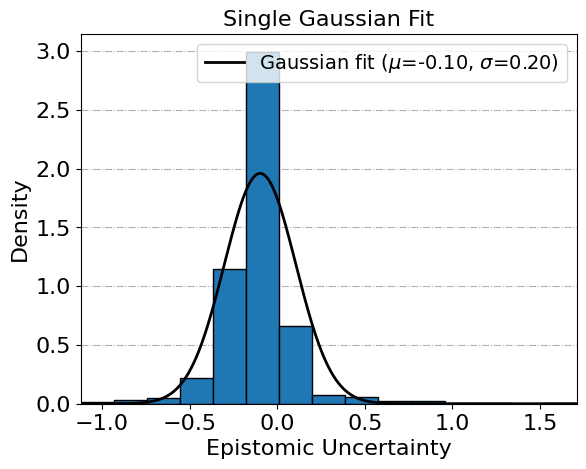

In [132]:
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
plt.rcParams.update({
        'font.size': 14,              # General font size
        'axes.titlesize': 16,         # Title font size
        'axes.labelsize': 16,         # Axis label font size
        'xtick.labelsize': 16,        # X-axis tick font size
        'ytick.labelsize': 16,        # Y-axis tick font size
        'legend.fontsize': 14         # Legend font size
    })


colormap = plt.cm.RdBu
colors = colormap(np.linspace(0.2, 1, 5))

fig, ax = plt.subplots()

# Example data
# epistomic_uncertainty = np.random.randn(100)

max_val = epistomic_uncertainty.max()
min_val = epistomic_uncertainty.min()
xx = np.linspace(min_val, max_val, 1000)

# Plot histogram
ax.hist(epistomic_uncertainty, bins=15, edgecolor='black', color="tab:blue", density=True, stacked=True, zorder=2)

# Fit a Gaussian (normal) distribution
mu, sigma = stats.norm.fit(epistomic_uncertainty)  # Maximum Likelihood Estimate
pdf = stats.norm.pdf(xx, mu, sigma)  # Evaluate PDF

# Plot the fitted Gaussian curve
ax.plot(xx, pdf, color="k", lw=2, label=f"Gaussian fit ($\mu$={mu:.2f}, $\sigma$={sigma:.2f})", zorder=2)

ax.set_xlabel("Epistomic Uncertainty")
ax.set_ylabel("Density")
ax.set_title("Single Gaussian Fit")
ax.set_xlim(min_val, max_val)
ax.grid(which='major', axis='y', linestyle='-.', zorder=0)
ax.legend()
# plt.savefig(f"results/figures/single_gaussian_okvqa.png", dpi=200, bbox_inches="tight")
plt.show()


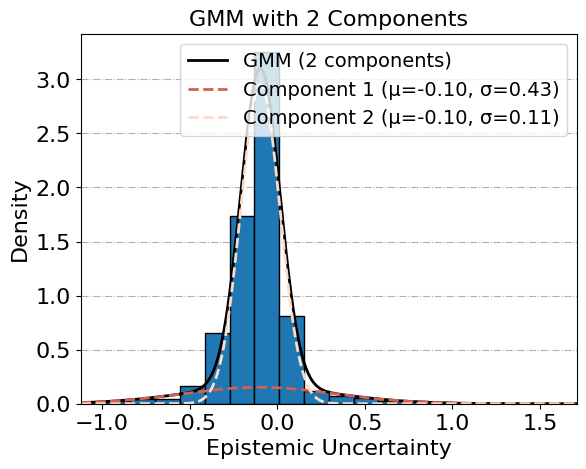

In [133]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# Example: your variable name
# epistomic_uncertainty = np.array(...)

# Step 1: standardize or log-transform if highly skewed
x = np.array(epistomic_uncertainty).reshape(-1, 1)
x_scaled = StandardScaler().fit_transform(x)

# Step 2: fit a more regularized GMM
gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    reg_covar=1e-2,      # prevents singular covariances
    random_state=0,
    init_params='kmeans' # better initialization
)
gmm.fit(x_scaled)

# Step 3: compute density
xx = np.linspace(x_scaled.min(), x_scaled.max(), 1000).reshape(-1, 1)
logprob = gmm.score_samples(xx)
pdf_scaled = np.exp(logprob)

# Convert grid back to original space
xx_orig = xx * np.std(epistomic_uncertainty) + np.mean(epistomic_uncertainty)

# Histogram
fig, ax = plt.subplots()
ax.hist(epistomic_uncertainty, bins=20, density=True, alpha=1,
        color='tab:blue', edgecolor='black', zorder=2)

# Step 4: plot mixture and components
ax.plot(xx_orig, pdf_scaled / np.std(epistomic_uncertainty),
        color='k', lw=2, label='GMM (2 components)', zorder=2)

# Individual components
means = gmm.means_.flatten() * np.std(epistomic_uncertainty) + np.mean(epistomic_uncertainty)
covars = gmm.covariances_.flatten() * (np.std(epistomic_uncertainty)**2)
weights = gmm.weights_

for i, (m, c, w) in enumerate(zip(means, covars, weights)):
    comp_pdf = w * (1/np.sqrt(2*np.pi*c)) * np.exp(-0.5*((xx_orig.flatten()-m)**2)/c)
    ax.plot(xx_orig, comp_pdf, '--', lw=2, color=colors[i],
            label=f'Component {i+1} (μ={m:.2f}, σ={np.sqrt(c):.2f})', zorder=2)

ax.set_xlabel("Epistemic Uncertainty")
ax.set_ylabel("Density")
ax.set_title("GMM with 2 Components")
ax.legend(loc="upper right")
ax.grid(which='major', axis='y', linestyle='-.', zorder=0)
ax.set_xlim(epistomic_uncertainty.min(), epistomic_uncertainty.max())
# plt.savefig(f"results/figures/gmm_okvqa.png", dpi=200, bbox_inches="tight")
plt.show()


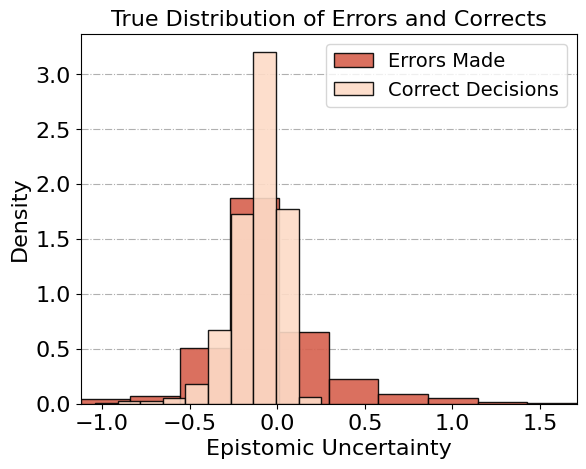

In [134]:
import matplotlib.pyplot as plt
from scipy import stats

fig, ax = plt.subplots()


max_val = epistomic_uncertainty.max()
min_val = epistomic_uncertainty.min()
xx = np.linspace(min_val, max_val, 1000)
ax.hist(epistomic_uncertainty[err_idx], bins=10, alpha=0.9, edgecolor='black', color=colors[0], label=f"Errors Made", density=True, stacked=True, zorder=3)
# kde = stats.gaussian_kde(epistomic_uncertainty[error_idx])
# ax.plot(xx, kde(xx), color='k', lw=2)

idx_rev = (~err_idx)
ax.hist(epistomic_uncertainty[idx_rev], bins=10, alpha=0.9, edgecolor='black', color=colors[1], label=f"Correct Decisions", density=True, stacked=True, zorder=3)
kde = stats.gaussian_kde(epistomic_uncertainty[idx_rev])
# ax.plot(xx, kde(xx), color=colors[-1], lw=2)


ax.set_xlabel("Epistomic Uncertainty")
ax.set_ylabel("Density")
ax.set_title(f"True Distribution of Errors and Corrects")

ax.set_xlim(min_val, max_val)
ax.grid(which='major', axis='y', linestyle='-.', zorder=0)
# plt.savefig(f"results/figures/true_dist_okvqa.png", dpi=200, bbox_inches="tight")
ax.legend()

In [140]:
import numpy as np
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

def adaptive_entropy_threshold(entropies, alpha=10.0):
    entropies = np.array(entropies).reshape(-1, 1)

    # --- single Gaussian ---
    mu, sigma = np.mean(entropies), np.std(entropies)
    logL1 = np.sum(norm.logpdf(entropies, mu, sigma))

    # --- two-component GMM ---
    gmm = GaussianMixture(n_components=2, covariance_type='full',
                          reg_covar=1e-3,      # prevents singular covariances
                          random_state=0)
    gmm.fit(entropies)
    logL2 = gmm.score(entropies) * len(entropies)

    # --- model selection ---
    print(logL2, logL1)
    if (logL2 - logL1) > alpha:
        print("GMM with 2 components selected")
        labels = gmm.predict(entropies)
        group0 = entropies[labels == 0]
        group1 = entropies[labels == 1]
        tau = min(max(group0), max(group1))  # boundary between clusters
    else:
        print("Single Gaussian selected")
        tau = mu + 2 * sigma  # conservative high-entropy cutoff

    return tau



In [164]:
tau = adaptive_entropy_threshold(epistomic_uncertainty, alpha=10.0)[0]
print("tau", tau)

1168.2665166449556 518.2294950511346
GMM with 2 components selected
tau 0.20065323


In [168]:
idx = epistomic_uncertainty < tau
print( idx.sum() / len(idx), np.mean(result_dict["labels"][idx] == result_dict["predictions"][idx]))

0.9646784405198268 0.7595854922279792


In [160]:
print(np.mean(result_dict["labels"] == result_dict["predictions"]))

0.7344218593802065


In [161]:
np.mean(result_dict["labels"] == data_df["generated_outputs"].values)

0.7420859713428857

In [162]:
ens_pred_copy = result_dict["predictions"].copy()
ens_pred_copy[idx] = data_df["generated_outputs"].values[idx]
print(np.mean(result_dict["labels"] == ens_pred_copy))

0.7420859713428857
